# Workshop 2: Retrieval Basics with RAG
## Theme Example: Literature (Shakespeare)

In this workshop, we move from raw text to retrieval.  
The goal is to prepare documents, split them into smaller chunks, and build a simple retrieval system that can return relevant passages for a user query.

We start with the Literature theme because it uses clean text and is easier to work with before moving to more complex datasets such as XML or PDF files.

By the end of this notebook, you will be able to:
- load a text dataset
- split the text into chunks
- create embeddings for those chunks
- store them in a vector database
- retrieve the most relevant chunks for a query

## 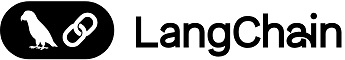


LangChain is a framework designed to help developers build applications using Large Language Models (LLMs).

In this workshop, we use LangChain to simplify key steps in building a RAG system:

- **Text Splitting** → breaking large documents into smaller chunks  
- **Embeddings** → converting text into numerical representations  
- **Vector Stores** → storing and searching chunks efficiently  
- **Retrieval** → finding the most relevant pieces of information  

LangChain provides ready-to-use components for each of these steps, allowing us to focus on building the overall pipeline rather than implementing everything from scratch.

In [1]:
# Install required libraries (run once)
!pip install -q --upgrade langchain langchain-community langchain-text-splitters sentence-transformers faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [2]:
#Library imports
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

## Loading the Dataset (Shakespeare)

We will use a public dataset containing Shakespeare’s works from Project Gutenberg.

This is a plain text dataset, which makes it ideal for learning the basics of retrieval before working with more complex data formats.

In this step, we load the text and prepare it for processing.

In [3]:
# Load Shakespeare text from Project Gutenberg
import requests

url = "https://www.gutenberg.org/files/100/100-0.txt"
response = requests.get(url)
text = response.text

# Print a preview
print(text[:1000])

*** START OF THE PROJECT GUTENBERG EBOOK 100 ***




The Complete Works of William Shakespeare

by William Shakespeare




                    Contents

    THE SONNETS
    ALL’S WELL THAT ENDS WELL
    THE TRAGEDY OF ANTONY AND CLEOPATRA
    AS YOU LIKE IT
    THE COMEDY OF ERRORS
    THE TRAGEDY OF CORIOLANUS
    CYMBELINE
    THE TRAGEDY OF HAMLET, PRINCE OF DENMARK
    THE FIRST PART OF KING HENRY THE FOURTH
    THE SECOND PART OF KING HENRY THE FOURTH
    THE LIFE OF KING HENRY THE FIFTH
    THE FIRST PART OF HENRY THE SIXTH
    THE SECOND PART OF KING HENRY THE SIXTH
    THE THIRD PART OF KING HENRY THE SIXTH
    KING HENRY THE EIGHTH
    THE LIFE AND DEATH OF KING JOHN
    THE TRAGEDY OF JULIUS CAESAR
    THE TRAGEDY OF KING LEAR
    LOVE’S LABOUR’S LOST
    THE TRAGEDY OF MACBETH
    MEASURE FOR MEASURE
    THE MERCHANT OF VENICE
    THE MERRY WIVES OF WINDSOR
    A MIDSUMMER NIGHT’S DREAM
    MUCH ADO ABOUT NOTHING
    THE TRAGEDY OF OTHELLO, THE MOOR OF VENICE
    PERICLES, P

## Splitting Text into Chunks

Large documents are difficult to process directly.  
Instead, we split the text into smaller pieces called *chunks*.

This helps:
- improve retrieval accuracy  
- reduce irrelevant information  
- make processing more efficient  

We also allow a small overlap between chunks to preserve context.

In [6]:
# Split text into chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=150 #Overlap ensures that key information appears in more than one chunk, so retrieval is more reliable
)

chunks = splitter.split_text(text)

# Preview
print(f"Number of chunks: {len(chunks)}")
print(chunks[0])

Number of chunks: 4323
*** START OF THE PROJECT GUTENBERG EBOOK 100 ***




The Complete Works of William Shakespeare

by William Shakespeare




                    Contents

    THE SONNETS
    ALL’S WELL THAT ENDS WELL
    THE TRAGEDY OF ANTONY AND CLEOPATRA
    AS YOU LIKE IT
    THE COMEDY OF ERRORS
    THE TRAGEDY OF CORIOLANUS
    CYMBELINE
    THE TRAGEDY OF HAMLET, PRINCE OF DENMARK
    THE FIRST PART OF KING HENRY THE FOURTH
    THE SECOND PART OF KING HENRY THE FOURTH
    THE LIFE OF KING HENRY THE FIFTH
    THE FIRST PART OF HENRY THE SIXTH
    THE SECOND PART OF KING HENRY THE SIXTH
    THE THIRD PART OF KING HENRY THE SIXTH
    KING HENRY THE EIGHTH
    THE LIFE AND DEATH OF KING JOHN
    THE TRAGEDY OF JULIUS CAESAR
    THE TRAGEDY OF KING LEAR
    LOVE’S LABOUR’S LOST
    THE TRAGEDY OF MACBETH
    MEASURE FOR MEASURE
    THE MERCHANT OF VENICE
    THE MERRY WIVES OF WINDSOR
    A MIDSUMMER NIGHT’S DREAM
    MUCH ADO ABOUT NOTHING
    THE TRAGEDY OF OTHELLO, THE MOOR OF

In [7]:
# Example of content overlap between chunks
print("Chunk 6 (end):")
print(chunks[6][-200:])  # last part of chunk 6

print("\n" + "-"*50 + "\n")

print("Chunk 7 (start):")
print(chunks[7][:200])   # first part of chunk 7

Chunk 6 (end):
uties do themselves forsake,
And die as fast as they see others grow,
  And nothing ’gainst Time’s scythe can make defence
  Save breed to brave him, when he takes thee hence.


                    13

--------------------------------------------------

Chunk 7 (start):
13

O that you were your self, but love you are
No longer yours, than you yourself here live,
Against this coming end you should prepare,
And your sweet semblance to some other give.
So should that be


## Creating Embeddings and Vector Store

To enable semantic search, we convert each text chunk into a numerical representation called an *embedding*.

Embeddings capture the meaning of the text, allowing us to find similar content even if the exact words are different.

We then store these embeddings in a vector database (FAISS), which allows efficient similarity search.

## What is FAISS?

FAISS (Facebook AI Similarity Search) is a library used for efficient similarity search over large collections of vectors.

In this workshop, FAISS is used as a **vector database** to store embeddings of text chunks and quickly retrieve the most relevant ones for a given query.

Key idea:
- Each chunk → converted into a vector (embedding)  
- FAISS → finds the closest vectors to a query  

This allows us to perform **semantic search**, meaning we retrieve information based on meaning rather than exact keyword matching.

In [8]:
# Create embeddings
embedding_model = HuggingFaceEmbeddings()

# Create vector store
db = FAISS.from_texts(chunks, embedding_model)

print("Vector store created successfully!")

/tmp/ipykernel_5859/2835896228.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings()
/tmp/ipykernel_5859/2835896228.py:2: LangChainDeprecationWarning: Default values for HuggingFaceEmbeddings.model_name were deprecated in LangChain 0.2.16 and will be removed in 0.4.0. Explicitly pass a model_name to the HuggingFaceEmbeddings constructor instead.
  embedding_model = HuggingFaceEmbeddings()
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/s

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Vector store created successfully!


## Retrieving Relevant Information

Now that we have stored our text chunks in a vector database, we can perform **semantic search**.

Given a query, the system will:
- convert the query into an embedding  
- compare it with stored embeddings  
- return the most relevant chunks  

This is the core step in Retrieval-Augmented Generation (RAG).

In [9]:
# Example query
query = "power and kings"

# Retrieve top 3 relevant chunks
results = db.similarity_search(query, k=3)

# Display results
for i, r in enumerate(results):
    print(f"\nResult {i+1}:\n")
    print(r.page_content[:500])


Result 1:

“All which together, like a troubled ocean,
Beat at thy rocky and wrack-threat’ning heart,
To soften it with their continual motion;
For stones dissolved to water do convert.
O, if no harder than a stone thou art,
    Melt at my tears and be compassionate!
    Soft pity enters at an iron gate.

“In Tarquin’s likeness I did entertain thee.
Hast thou put on his shape to do him shame?
To all the host of heaven I complain me,
Thou wrong’st his honour, wound’st his princely name.
Thou art not what th

Result 2:

KING.
You are right, justice, and you weigh this well.
Therefore still bear the balance and the sword.
And I do wish your honours may increase
Till you do live to see a son of mine
Offend you and obey you, as I did.
So shall I live to speak my father’s words:
“Happy am I, that have a man so bold
That dares do justice on my proper son;
And not less happy, having such a son
That would deliver up his greatness so
Into the hands of justice.” You did commit me,
For which I do

## Evaluating Retrieval: Precision@k

A simple way to evaluate retrieval quality is **Precision@k**.

It measures how many of the top *k* retrieved results are actually relevant to the query.

$$
\text{Precision@k} = \frac{\text{Number of relevant results in top k}}{k}
$$

Example:
- If we retrieve 3 results (k = 3)  
- and 2 of them are relevant  
→ Precision@3 = 2/3  

In this workshop, we use a simple manual check of relevance, but this metric is commonly used in real systems.

## Summary

In this notebook, we:
- loaded a dataset  
- split it into chunks  
- created embeddings  
- stored them in a vector database  
- retrieved relevant information using queries  

This is the **retrieval part of a RAG system**.

Next, we will use these retrieved chunks to generate answers using a language model.